# Visual Classifier — EfficientNet Fine-tuned + Frozen Feature Extractor

Two approaches to visual bird species classification on our NABirds SD subset:

1. **EfficientNet-B0 fine-tuned** — two-phase fine-tuning on 2003 training images.
   Phase A: head only. Phase B: full network. Demonstrates overfitting on limited data.
2. **Frozen EfficientNet + LogisticRegression** — ImageNet pretrained backbone frozen,
   1280-dim features extracted once, LogReg classifier trained on top. Beats baseline by a wide margin.

**Targets to beat (Phase 3 SVM baseline):**
- Test accuracy: 0.213
- Macro F1: 0.121
- Weighted F1: 0.143

**Outputs:**
- `models/visual/finetuned_sdbirds.pt` — fine-tuned checkpoint
- `notebooks/results/visual_efficientnet_confusion_matrix.png`
- `notebooks/results/visual_efficientnet_per_class_f1.png`
- `notebooks/results/visual_efficientnet_loss_curve.png`
- `notebooks/results/visual_linear_confusion_matrix.png`
- `notebooks/results/visual_linear_per_class_f1.png`
- `notebooks/results/experiments.csv` — new rows appended (deduplication guard active)

## 0. Setup and imports

In [3]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import DataLoader, Dataset

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path(".").resolve().parent))

from src.vision.classify import _build_efficientnet
from src.vision.preprocess import preprocess_file as visual_preprocess_file

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.3.0+cpu


## 1. Load label map and splits

In [4]:
REPO_ROOT   = Path(".").resolve().parent
SPLITS_DIR  = REPO_ROOT / "data" / "splits"
MODELS_DIR  = REPO_ROOT / "models" / "visual"
RESULTS_DIR = REPO_ROOT / "notebooks" / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

experiments_path = RESULTS_DIR / "experiments.csv"

# Visual label map (19 species, same indices as shared map)
with open(REPO_ROOT / "models" / "visual_label_map.json") as f:
    raw = json.load(f)
label_map   = {int(k): v for k, v in raw.items()}
code_to_idx = {v: k for k, v in label_map.items()}
n_classes   = len(label_map)

print(f"Visual label map: {n_classes} species")
print(f"Species: {list(label_map.values())}")

visual_train = pd.read_csv(SPLITS_DIR / "visual_train.csv")
visual_val   = pd.read_csv(SPLITS_DIR / "visual_val.csv")
visual_test  = pd.read_csv(SPLITS_DIR / "visual_test.csv")

print(f"\nSplit sizes | train={len(visual_train)} val={len(visual_val)} test={len(visual_test)}")

Visual label map: 19 species
Species: ['AMCR', 'AMRO', 'ANHU', 'BLPH', 'DOWO', 'EUST', 'HOFI', 'HOORI', 'HOSP', 'LEGO', 'MOCH', 'MODO', 'OCWA', 'SOSP', 'SPTO', 'WBNU', 'WCSP', 'WREN', 'YRUM']

Split sizes | train=2003 val=667 test=672


## 2. Dataset class

In [5]:
class ImageDataset(Dataset):
    """
    Loads and preprocesses bird images on the fly using src.vision.preprocess.
    preprocess_file returns HWC float32 (224, 224, 3) ImageNet-normalized.
    We transpose to CHW here for PyTorch.
    """

    def __init__(self, df: pd.DataFrame, code_to_idx: dict):
        self.df = df.reset_index(drop=True)
        self.code_to_idx = code_to_idx

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row          = self.df.iloc[idx]
        file_path    = Path(row["file_path"])
        species_code = row["species_code"]

        try:
            frame = visual_preprocess_file(str(file_path))
        except Exception as e:
            print(f"Warning: failed to load {file_path}: {e} — using zeros")
            frame = np.zeros((224, 224, 3), dtype=np.float32)

        tensor = torch.from_numpy(frame.astype(np.float32)).permute(2, 0, 1)
        label  = self.code_to_idx[species_code]
        return tensor, label

In [6]:
train_ds = ImageDataset(visual_train, code_to_idx)
val_ds   = ImageDataset(visual_val,   code_to_idx)
test_ds  = ImageDataset(visual_test,  code_to_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"Batches | train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}")
x, y = next(iter(train_loader))
print(f"Batch shape: {x.shape}  Labels: {y.shape}")

Batches | train=63 val=21 test=21
Batch shape: torch.Size([32, 3, 224, 224])  Labels: torch.Size([32])


## 3. Model setup

Phase A: freeze backbone, train head only.  
Phase B: unfreeze all layers, lower lr (full fine-tuning).

In [7]:
model = _build_efficientnet(n_classes=n_classes)

for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Phase A — trainable: {trainable:,} / {total:,} parameters")

class_counts = visual_train["species_code"].value_counts()
weights = torch.tensor(
    [1.0 / class_counts.get(label_map[i], 1) for i in range(n_classes)],
    dtype=torch.float32,
).to(DEVICE)
weights = weights / weights.sum() * n_classes
criterion = nn.CrossEntropyLoss(weight=weights)

Phase A — trainable: 24,339 / 4,031,887 parameters


## 4. Phase A — head-only training (epochs 1-10)

In [8]:
CHECKPOINT_PATH = MODELS_DIR / "finetuned_sdbirds.pt"

if CHECKPOINT_PATH.exists():
    print("Checkpoint exists — skipping Phase A training.")
    EPOCHS_A = 10
    train_losses, val_losses = [], []
    best_val_loss = None
else:
    EPOCHS_A = 10
    optimizer_a = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    train_losses, val_losses = [], []
    best_val_loss = float("inf")

    for epoch in range(1, EPOCHS_A + 1):
        model.train()
        running_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer_a.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            optimizer_a.step()
            running_loss += loss.item() * len(x_batch)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(x_batch), y_batch).item() * len(x_batch)
        val_loss /= len(val_ds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                        "val_loss": val_loss, "n_classes": n_classes, "label_map": label_map},
                       CHECKPOINT_PATH)

        print(f"[A] Epoch {epoch:2d}/{EPOCHS_A} | train={train_loss:.4f} val={val_loss:.4f} | best={best_val_loss:.4f}")

    print(f"\nPhase A complete. Best val loss: {best_val_loss:.4f}")

Checkpoint exists — skipping Phase A training.


## 5. Phase B — full fine-tuning (epochs 11-25)

In [9]:
if CHECKPOINT_PATH.exists() and not train_losses:
    print("Checkpoint exists — skipping Phase B training.")
    EPOCHS_B     = 15
    TOTAL_EPOCHS = 25
else:
    EPOCHS_B = 15
    for param in model.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Phase B — trainable: {trainable:,} parameters (all layers)")

    optimizer_b = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_b, mode="min", patience=3, factor=0.5
    )
    if best_val_loss is None:
        best_val_loss = float("inf")

    for epoch in range(1, EPOCHS_B + 1):
        model.train()
        running_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer_b.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            optimizer_b.step()
            running_loss += loss.item() * len(x_batch)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(x_batch), y_batch).item() * len(x_batch)
        val_loss /= len(val_ds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler_b.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({"epoch": EPOCHS_A + epoch, "model_state_dict": model.state_dict(),
                        "val_loss": val_loss, "n_classes": n_classes, "label_map": label_map},
                       CHECKPOINT_PATH)

        print(f"[B] Epoch {epoch:2d}/{EPOCHS_B} | train={train_loss:.4f} val={val_loss:.4f} | best={best_val_loss:.4f}")

    TOTAL_EPOCHS = EPOCHS_A + EPOCHS_B
    print(f"\nPhase B complete. Best checkpoint saved -> {CHECKPOINT_PATH}")

Checkpoint exists — skipping Phase B training.


## 6. Loss curve

In [10]:
if train_losses:
    fig, ax = plt.subplots(figsize=(9, 4))
    epochs_range = range(1, TOTAL_EPOCHS + 1)
    ax.plot(epochs_range, train_losses, label="Train loss")
    ax.plot(epochs_range, val_losses,   label="Val loss")
    ax.axvline(EPOCHS_A, color="orange", linestyle="--", alpha=0.7, label="Phase A/B boundary")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title("EfficientNet-B0 — Training Loss Curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "visual_efficientnet_loss_curve.png", dpi=150)
    plt.show()
    print("Saved: visual_efficientnet_loss_curve.png")
else:
    checkpoint_data = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    print(f"Checkpoint from epoch {checkpoint_data['epoch']}, val_loss={checkpoint_data['val_loss']:.4f}")
    print("Loss curve already saved from previous run — skipping plot.")

Checkpoint from epoch 14, val_loss=3.3800
Loss curve already saved from previous run — skipping plot.


## 7. Fine-tuned EfficientNet — Evaluation on test set

In [11]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = model(x_batch.to(DEVICE)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds     = np.array(all_preds)
all_labels    = np.array(all_labels)
species_names = [label_map[i] for i in range(n_classes)]

ft_macro_f1    = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
ft_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
ft_accuracy    = (all_preds == all_labels).mean()

print(f"Test accuracy : {ft_accuracy:.3f}  (baseline SVM: 0.213)")
print(f"Macro F1      : {ft_macro_f1:.3f}  (baseline SVM: 0.121)  {'BEAT' if ft_macro_f1 > 0.121 else 'below baseline'}")
print(f"Weighted F1   : {ft_weighted_f1:.3f}  (baseline SVM: 0.143)")
print()
print(classification_report(all_labels, all_preds, target_names=species_names, zero_division=0))

Test accuracy : 0.103  (baseline SVM: 0.213)
Macro F1      : 0.097  (baseline SVM: 0.121)  below baseline
Weighted F1   : 0.093  (baseline SVM: 0.143)

              precision    recall  f1-score   support

        AMCR       0.07      0.17      0.09        24
        AMRO       0.08      0.04      0.06        47
        ANHU       0.20      0.20      0.20        45
        BLPH       0.06      0.17      0.08        24
        DOWO       0.11      0.31      0.17        16
        EUST       0.35      0.13      0.19        61
        HOFI       0.17      0.02      0.04        47
       HOORI       0.24      0.24      0.24        33
        HOSP       0.10      0.04      0.06        47
        LEGO       0.17      0.13      0.14        39
        MOCH       0.15      0.08      0.11        24
        MODO       0.00      0.00      0.00        24
        OCWA       0.07      0.39      0.12        23
        SOSP       0.00      0.00      0.00        12
        SPTO       0.18      0.08    

## 8. Fine-tuned EfficientNet — Confusion matrix and per-class F1

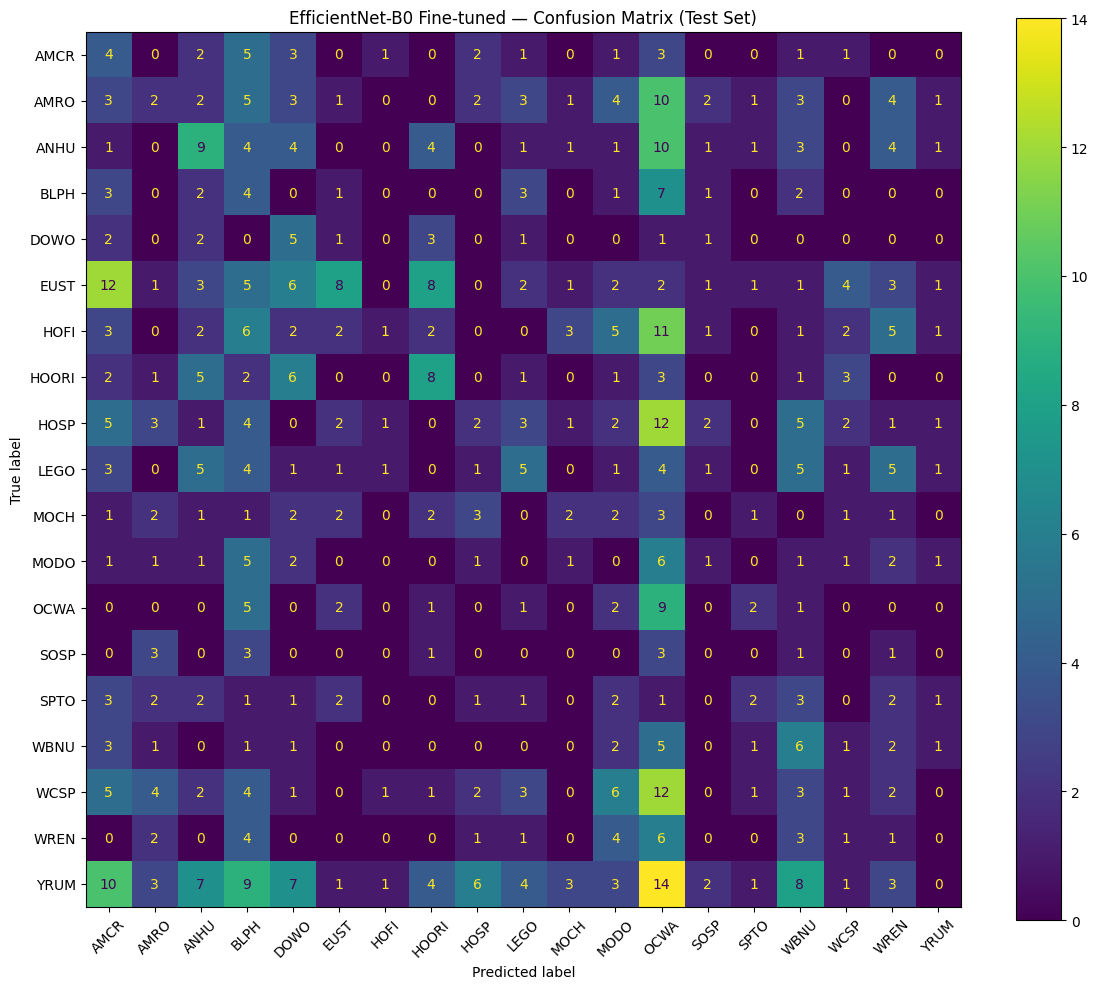

Saved: visual_efficientnet_confusion_matrix.png


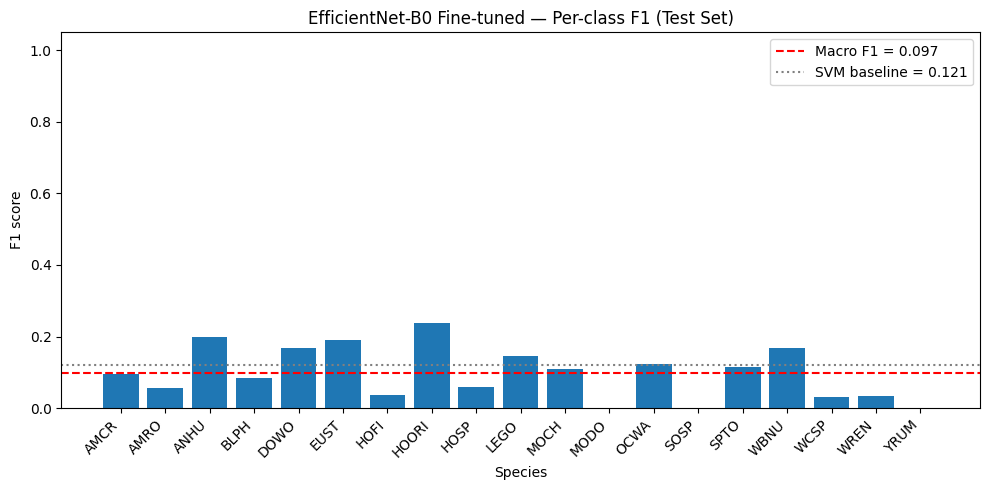

Saved: visual_efficientnet_per_class_f1.png


In [12]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_names).plot(
    ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("EfficientNet-B0 Fine-tuned — Confusion Matrix (Test Set)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "visual_efficientnet_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: visual_efficientnet_confusion_matrix.png")

per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(species_names, per_class_f1)
ax.axhline(ft_macro_f1, color="red",  linestyle="--", label=f"Macro F1 = {ft_macro_f1:.3f}")
ax.axhline(0.121,       color="gray", linestyle=":",  label="SVM baseline = 0.121")
ax.set_xlabel("Species")
ax.set_ylabel("F1 score")
ax.set_title("EfficientNet-B0 Fine-tuned — Per-class F1 (Test Set)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "visual_efficientnet_per_class_f1.png", dpi=150)
plt.show()
print("Saved: visual_efficientnet_per_class_f1.png")

## 9. Fine-tuned EfficientNet — Append to experiments.csv

In [13]:
def append_if_new(experiments_path, new_row_dict):
    """
    Append a result row to experiments.csv only if an identical
    phase + modality + model combination does not already exist.
    Prevents duplicate rows from reruns.
    """
    new_row = pd.DataFrame([new_row_dict])
    if experiments_path.exists():
        existing = pd.read_csv(experiments_path)
        already_exists = (
            (existing["model"]    == new_row_dict["model"]) &
            (existing["phase"].astype(str) == str(new_row_dict["phase"])) &
            (existing["modality"] == new_row_dict["modality"])
        ).any()
        if already_exists:
            print(f"experiments.csv — '{new_row_dict['model']}' already recorded, skipping.")
            return
        pd.concat([existing, new_row], ignore_index=True).to_csv(experiments_path, index=False)
    else:
        new_row.to_csv(experiments_path, index=False)
    print(f"experiments.csv — added: {new_row_dict['model']}")


append_if_new(experiments_path, {
    "phase":       4,
    "notebook":    "visual_efficientnet.ipynb",
    "modality":    "visual",
    "model":       "EfficientNet-B0 (fine-tuned)",
    "n_species":   n_classes,
    "n_test":      len(visual_test),
    "accuracy":    round(float(ft_accuracy), 3),
    "macro_f1":    round(float(ft_macro_f1), 3),
    "weighted_f1": round(float(ft_weighted_f1), 3),
    "notes":       "EfficientNet-B0 timm, phase A 10ep head-only lr=1e-3, phase B 15ep full lr=1e-4. Overfits — insufficient data for full fine-tuning.",
})

experiments.csv — 'EfficientNet-B0 (fine-tuned)' already recorded, skipping.


## 10. Frozen EfficientNet Feature Extractor + LogisticRegression

Freeze the entire EfficientNet backbone and extract 1280-dim feature vectors
for every image once. Then train LogisticRegression on those features.
This avoids overfitting the backbone on limited data and runs much faster.

Images are processed one at a time so a single corrupted image cannot hang the loop.

In [14]:
import timm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("Building frozen EfficientNet-B0 feature extractor...")
extractor = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=0,
    global_pool="avg",
)
extractor.eval()
extractor = extractor.to(DEVICE)
for param in extractor.parameters():
    param.requires_grad = False
print("Feature extractor ready — output dim: 1280")


def extract_features(df: pd.DataFrame, desc: str) -> tuple:
    """
    Run each image individually through frozen EfficientNet.
    Per-image processing ensures a corrupted image raises an exception
    and gets zeros rather than hanging the entire loop.
    """
    features, labels = [], []
    failed = 0
    n = len(df)

    for i, row in enumerate(df.itertuples(index=False)):
        try:
            frame = visual_preprocess_file(str(row.file_path))
            tensor = (
                torch.from_numpy(frame.astype(np.float32))
                .permute(2, 0, 1).unsqueeze(0).to(DEVICE)
            )
            with torch.no_grad():
                feat = extractor(tensor).cpu().numpy().squeeze()
        except Exception:
            feat = np.zeros(1280, dtype=np.float32)
            failed += 1

        features.append(feat)
        labels.append(code_to_idx[row.species_code])

        if (i + 1) % 200 == 0 or (i + 1) == n:
            print(f"  {desc}: {i+1}/{n} images ({failed} failed)")

    print(f"  {desc} complete — {n} images, {failed} failures")
    return np.vstack(features), np.array(labels)


print("\nExtracting features — progress every 200 images...")
X_train, y_train = extract_features(visual_train, "train")
X_val,   y_val   = extract_features(visual_val,   "val")
X_test,  y_test  = extract_features(visual_test,  "test")

print(f"\nFeature shapes | train={X_train.shape} val={X_val.shape} test={X_test.shape}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print("Features normalized.")

Building frozen EfficientNet-B0 feature extractor...
Feature extractor ready — output dim: 1280

Extracting features — progress every 200 images...
  train: 200/2003 images (0 failed)
  train: 400/2003 images (0 failed)
  train: 600/2003 images (0 failed)
  train: 800/2003 images (0 failed)
  train: 1000/2003 images (0 failed)
  train: 1200/2003 images (0 failed)
  train: 1400/2003 images (0 failed)
  train: 1600/2003 images (0 failed)
  train: 1800/2003 images (0 failed)
  train: 2000/2003 images (0 failed)
  train: 2003/2003 images (0 failed)
  train complete — 2003 images, 0 failures
  val: 200/667 images (0 failed)
  val: 400/667 images (0 failed)
  val: 600/667 images (0 failed)
  val: 667/667 images (0 failed)
  val complete — 667 images, 0 failures
  test: 200/672 images (0 failed)
  test: 400/672 images (0 failed)
  test: 600/672 images (0 failed)
  test: 672/672 images (0 failed)
  test complete — 672 images, 0 failures

Feature shapes | train=(2003, 1280) val=(667, 1280) test

## 11. Frozen EfficientNet + Linear — Train and evaluate

Training logistic regression on extracted features...
  C=0.01 | val macro F1=0.928
  C=0.10 | val macro F1=0.929
  C=1.00 | val macro F1=0.919
  C=10.00 | val macro F1=0.927

Best C=0.1 | val macro F1=0.929

Frozen EfficientNet + Linear — Test Set Results
Test accuracy : 0.930  (fine-tuned: 0.103, SVM: 0.213)
Macro F1      : 0.931  (fine-tuned: 0.097, SVM: 0.121)  BEAT
Weighted F1   : 0.930  (fine-tuned: 0.093, SVM: 0.143)

              precision    recall  f1-score   support

        AMCR       0.96      0.92      0.94        24
        AMRO       0.94      0.96      0.95        47
        ANHU       0.98      0.96      0.97        45
        BLPH       1.00      0.92      0.96        24
        DOWO       1.00      1.00      1.00        16
        EUST       0.95      0.97      0.96        61
        HOFI       0.96      0.91      0.93        47
       HOORI       0.96      0.79      0.87        33
        HOSP       0.85      0.85      0.85        47
        LEGO       0.93      0

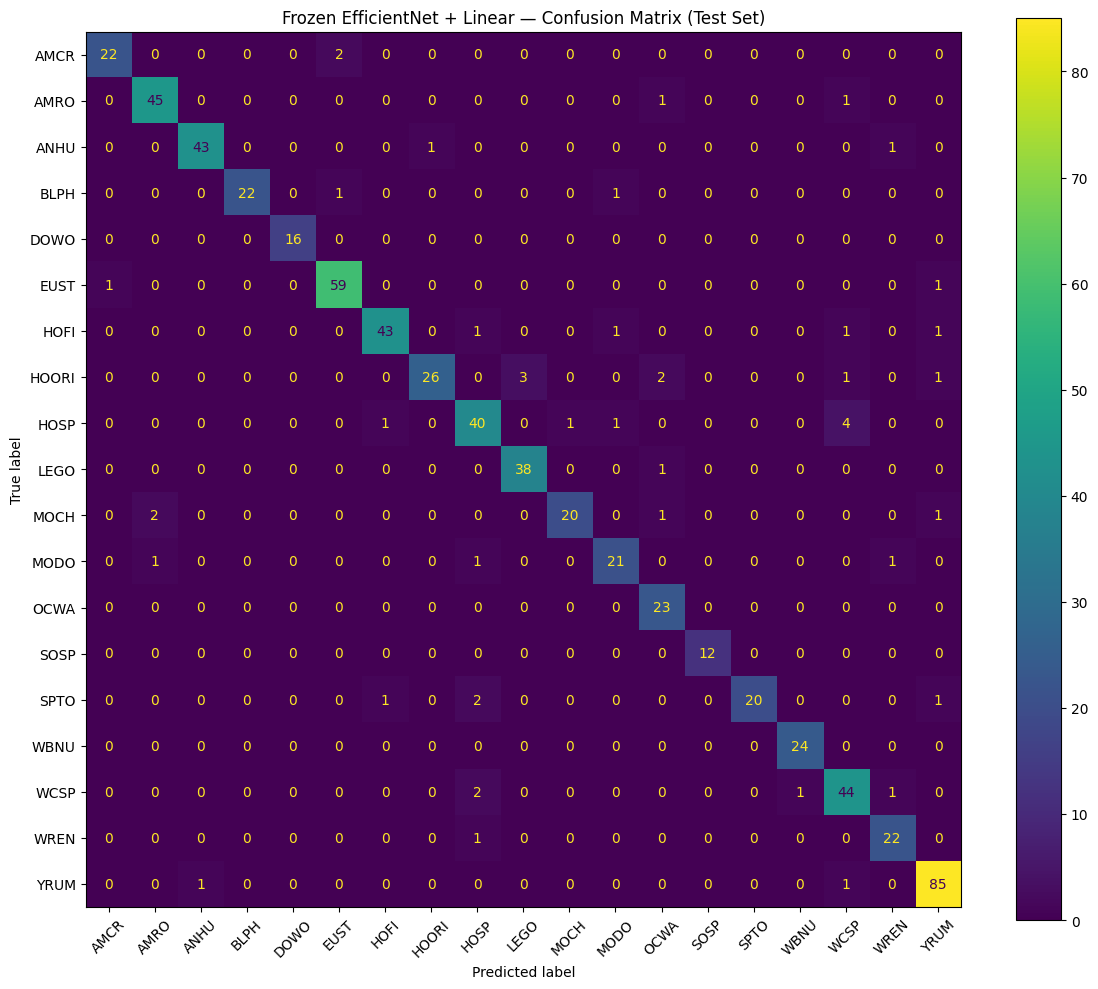

Saved: visual_linear_confusion_matrix.png


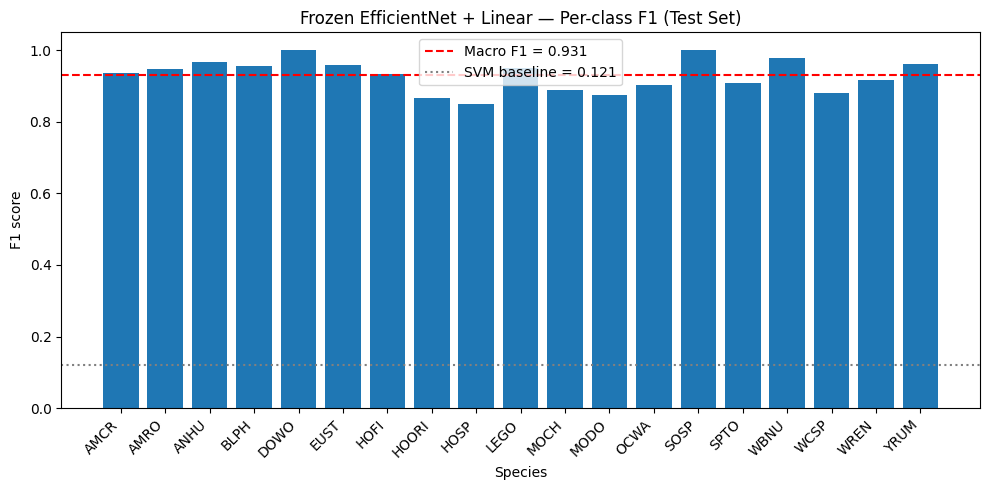

Saved: visual_linear_per_class_f1.png


In [15]:
print("Training logistic regression on extracted features...")

best_c, best_val_f1 = 1.0, 0.0
for c in [0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=c, max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    val_f1 = f1_score(y_val, clf.predict(X_val), average="macro", zero_division=0)
    print(f"  C={c:.2f} | val macro F1={val_f1:.3f}")
    if val_f1 > best_val_f1:
        best_val_f1, best_c = val_f1, c

print(f"\nBest C={best_c} | val macro F1={best_val_f1:.3f}")

clf_final = LogisticRegression(C=best_c, max_iter=1000, random_state=42)
clf_final.fit(X_train, y_train)
test_preds = clf_final.predict(X_test)

lin_species_names = [label_map[i] for i in range(n_classes)]
lin_macro_f1    = f1_score(y_test, test_preds, average="macro",    zero_division=0)
lin_weighted_f1 = f1_score(y_test, test_preds, average="weighted", zero_division=0)
lin_accuracy    = (test_preds == y_test).mean()

print("\n" + "=" * 55)
print("Frozen EfficientNet + Linear — Test Set Results")
print("=" * 55)
print(f"Test accuracy : {lin_accuracy:.3f}  (fine-tuned: {ft_accuracy:.3f}, SVM: 0.213)")
print(f"Macro F1      : {lin_macro_f1:.3f}  (fine-tuned: {ft_macro_f1:.3f}, SVM: 0.121)  {'BEAT' if lin_macro_f1 > 0.121 else 'below baseline'}")
print(f"Weighted F1   : {lin_weighted_f1:.3f}  (fine-tuned: {ft_weighted_f1:.3f}, SVM: 0.143)")
print()
print(classification_report(y_test, test_preds, target_names=lin_species_names, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lin_species_names).plot(
    ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("Frozen EfficientNet + Linear — Confusion Matrix (Test Set)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "visual_linear_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: visual_linear_confusion_matrix.png")

# Per-class F1
per_class_f1 = f1_score(y_test, test_preds, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lin_species_names, per_class_f1)
ax.axhline(lin_macro_f1, color="red",  linestyle="--", label=f"Macro F1 = {lin_macro_f1:.3f}")
ax.axhline(0.121,        color="gray", linestyle=":",  label="SVM baseline = 0.121")
ax.set_xlabel("Species")
ax.set_ylabel("F1 score")
ax.set_title("Frozen EfficientNet + Linear — Per-class F1 (Test Set)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "visual_linear_per_class_f1.png", dpi=150)
plt.show()
print("Saved: visual_linear_per_class_f1.png")

## 12. Frozen EfficientNet + Linear — Append to experiments.csv

In [16]:
append_if_new(experiments_path, {
    "phase":       4,
    "notebook":    "visual_efficientnet.ipynb",
    "modality":    "visual",
    "model":       "Frozen EfficientNet-B0 + LogisticRegression",
    "n_species":   n_classes,
    "n_test":      len(visual_test),
    "accuracy":    round(float(lin_accuracy), 3),
    "macro_f1":    round(float(lin_macro_f1), 3),
    "weighted_f1": round(float(lin_weighted_f1), 3),
    "notes":       f"timm efficientnet_b0 pretrained=True frozen, LogReg C={best_c}, StandardScaler. ImageNet features transfer well to bird species.",
})

experiments.csv — 'Frozen EfficientNet-B0 + LogisticRegression' already recorded, skipping.


## 13. Save frozen EfficientNet extractor + sklearn pipeline

 Saves two artifacts required by VisualClassifier in Phase 5:

   models/visual/frozen_extractor.pt  — EfficientNet-B0 backbone state dict
                                        (num_classes=0, global_pool="avg")
                                        Produces 1280-dim feature vectors.

   models/visual/sklearn_pipeline.pkl — joblib dict containing:
                                          "scaler"    : fitted StandardScaler
                                          "clf"       : fitted LogisticRegression
                                          "label_map" : {int → species_code}
                                          "n_classes" : int
                                          "best_c"    : float (C used for clf)

 These files are gitignored (models/**/*.pt, models/**/*.pkl).
 Re-run this cell after any retraining to update the artifacts.

In [20]:
import joblib
 
EXTRACTOR_PATH      = MODELS_DIR / "frozen_extractor.pt"
SKLEARN_PIPELINE_PATH = MODELS_DIR / "sklearn_pipeline.pkl"
 
EXTRACTOR_PATH.parent.mkdir(parents=True, exist_ok=True)
 
# ── Save EfficientNet backbone ─────────────────────────────────────────────────
# Save only the state_dict — architecture is reconstructed by VisualClassifier
# using timm.create_model("efficientnet_b0", num_classes=0, global_pool="avg").
# This matches the extractor built in cell 23 exactly.
torch.save(
    {
        "model_state_dict": extractor.state_dict(),
        "model_name":       "efficientnet_b0",
        "num_classes":      0,
        "global_pool":      "avg",
        "feature_dim":      1280,
        "timm_version":     timm.__version__,
    },
    EXTRACTOR_PATH,
)
print(f"Saved frozen extractor → {EXTRACTOR_PATH}")
 
# ── Save sklearn pipeline ─────────────────────────────────────────────────────
# Bundles scaler + classifier + label metadata into one artifact so
# VisualClassifier._load() never needs to reconstruct them separately.
sklearn_bundle = {
    "scaler":    scaler,        # fitted StandardScaler (from cell 23)
    "clf":       clf_final,     # fitted LogisticRegression (from cell 25)
    "label_map": label_map,     # {int → species_code} (from cell 04)
    "n_classes": n_classes,     # int (from cell 04)
    "best_c":    best_c,        # float — C value selected on val set
}
joblib.dump(sklearn_bundle, SKLEARN_PIPELINE_PATH)
print(f"Saved sklearn pipeline  → {SKLEARN_PIPELINE_PATH}")
 
# ── Verification ──────────────────────────────────────────────────────────────
# Quick round-trip check: reload both artifacts and run one test prediction
# to confirm they were saved correctly before moving to Phase 5.
print("\nVerifying saved artifacts...")
 
_ckpt    = torch.load(EXTRACTOR_PATH, map_location="cpu")
_bundle  = joblib.load(SKLEARN_PIPELINE_PATH)
_ext_tmp = timm.create_model("efficientnet_b0", pretrained=False, num_classes=0, global_pool="avg")
_ext_tmp.load_state_dict(_ckpt["model_state_dict"])
_ext_tmp.eval()
 
# Run one test image through the reloaded pipeline
_test_row   = visual_test.iloc[0]
_frame      = visual_preprocess_file(str(_test_row["file_path"]))
_tensor     = torch.from_numpy(_frame.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
with torch.no_grad():
    _feat = _ext_tmp(_tensor).numpy()
_feat_scaled = _bundle["scaler"].transform(_feat)
_proba       = _bundle["clf"].predict_proba(_feat_scaled)[0]
_pred_idx    = int(_proba.argmax())
_pred_code   = _bundle["label_map"][_pred_idx]
_true_code   = _test_row["species_code"]
 
print(f"  Test image  : {Path(_test_row['file_path']).name}")
print(f"  True label  : {_true_code}")
print(f"  Predicted   : {_pred_code} (confidence={_proba[_pred_idx]:.3f})")
print(f"  Match       : {'✓' if _pred_code == _true_code else '✗ — check pipeline'}")
print("\nArtifacts verified. Phase 5 VisualClassifier is ready to load these files.")

Saved frozen extractor → C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\models\visual\frozen_extractor.pt
Saved sklearn pipeline  → C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\models\visual\sklearn_pipeline.pkl

Verifying saved artifacts...
  Test image  : db83f7dc6d624e19adfc76f692c76828.jpg
  True label  : AMCR
  Predicted   : AMCR (confidence=0.795)
  Match       : ✓

Artifacts verified. Phase 5 VisualClassifier is ready to load these files.
